# Neural machine translation: Transformer

In this demo, we implement a Transformer encoder-decoder model for our English-to-French translation task. The Transformer architecture differs fundamentally from RNN-based models by replacing recurrent layer entirely with **parallel attention**. Instead of processing tokens one at a time (like LSTMs), transformers process all tokens simultaneously using attention to capture relationships between words at any distance.

Recurrence is not necessary for sequence modeling. Transformers achieve better long-range dependency modeling with explicit positional encoding and self-attention and are being much faster to train due to parallelization.

### Key improvements

| LSTM + attention | Transformer |
|------------------|-------------|
| Sequential processing (one token at a time) | Parallel processing (all tokens simultaneously) |
| Position encoded implicitly through recurrence | Position encoded explicitly (sine/cosine functions) |
| Attention only in decoder (to encoder) | Self-attention in both encoder and decoder |
| Hidden states carry information forward | All positions attend to all positions |
| Slow training (cannot parallelize timesteps) | Fast training (full parallelization) |

### How transformers work

The original Transformer architecture consisted of an encoder-decoder architecture where both use **stacked attention layers** instead of recurrent layers.

**1. Positional encoding**

Since there's no recurrence to track position, we explicitly add positional information to the embeddings. The positional encoding is computed using sine and cosine functions of different frequencies:

$$\text{PE}(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

$$\text{PE}(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Where $pos$ is the position in the sequence (which token: 0, 1, 2, ...) and $i$ is the dimension index within the embedding vector (which element: 0, 1, 2, ..., $d_{\text{model}}$-1). Each position gets a unique encoding pattern across all embedding dimensions, with different dimensions using different frequencies.

The positional encoding has the same dimensionality as the token embeddings ($d_{\text{model}}$), so they are **added element-wise**:

$$\text{input} = \text{embedding}(\text{token}) + \text{PE}(pos)$$

For example, the token "cat" at position 1 gets: `embedding("cat") + PE(1)`. This creates a single vector per token containing both semantic information (what the token means) and positional information (where it is in the sequence). These functions allow the model to learn to attend to relative positions, since for any fixed offset $k$, $\text{PE}(pos+k)$ can be represented as a linear function of $\text{PE}(pos)$.

**2. Encoder self-attention**

Each encoder layer applies **self-attention**, where every token attends to all other tokens in the input sequence:

```text
Input:    "The"    "cat"    "sat"

Self-attention allows:
  "The" to attend to ["The", "cat", "sat"]
  "cat" to attend to ["The", "cat", "sat"]  
  "sat" to attend to ["The", "cat", "sat"]
```

This captures relationships like subject-verb agreement and word dependencies regardless of distance. The attention mechanism works in several steps:

**Step 1: Create query, key, and value representations**

For each token embedding (e.g., 256 dimensions), the model learns weight matrices to project into query and key/value spaces:

```text
Input embedding for "cat": [0.2, -0.5, 0.8, ..., 0.3]  (256 dims)

Multiply by learned weight matrices:
Q["cat"] = input × W^Q  →  [0.1,  0.4, ..., 0.2]  (256 dims)
K["cat"] = input × W^K  →  [0.3, -0.1, ..., 0.5]  (256 dims)
V["cat"] = K["cat"]                               (same as key)
```

Note: In this simplified implementation, the key and value are the same (both from $W^K$). The weight matrices $W^Q$ and $W^K$ are learned during training.

**Step 2: Compute attention scores**

Calculate dot-product similarity between queries and keys to get attention weights:

```text
        Key: "The"  "cat"  "sat"
Query:
"The"       0.8     0.1    0.1
"cat"       0.2     0.6    0.2
"sat"       0.1     0.3    0.6
```

Each row shows how much that token attends to all other tokens (after softmax normalization). For example, "cat" attends mostly to itself (0.6) with some attention to "The" (0.2) and "sat" (0.2).

**Step 3: Compute weighted output**

Multiply the attention weights by the value vectors to create new representations:

$$\text{attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

For token "cat": 

```text
output = 0.2 × V["The"] + 0.6 × V["cat"] + 0.2 × V["sat"]
```

This produces a new 256-dimensional vector that mixes information from all positions, weighted by attention. The output is not just the attention scores but a rich representation encoding both content and context.

**3. Masked self-attention in decoder**

During training, the decoder uses **masked self-attention** to prevent positions from attending to future positions (maintaining the autoregressive property):

```text
Target:   "<s>"  "Le"   "chat"

Masked self-attention:
  "<s>"  can attend to ["<s>"]
  "Le"   can attend to ["<s>", "Le"]
  "chat" can attend to ["<s>", "Le", "chat"]
```

This ensures the model learns to predict the next token using only previous context.

**4. Cross-attention**

After self-attention, the decoder applies **cross-attention** to the encoder outputs (same concept as LSTM attention):

```text
Encoder outputs: ["The", "cat", "sat"]
Decoder position: "chat"

Cross-attention: "chat" attends to ["The", "cat", "sat"]
  → High attention on "cat"
  → Low attention on "The" and "sat"
```

This allows the decoder to focus on relevant parts of the source sentence when generating each target token.

**5. Layer stacking and residual connections**

Both encoder and decoder consist of $N$ identical layers stacked on top of each other. Each layer has:
- Attention sub-layer (self or cross)
- Feed-forward sub-layer (two linear transformations with ReLU)
- Residual connections around each sub-layer
- Layer normalization after each sub-layer

The residual connections ($\text{output} = \text{LayerNorm}(x + \text{Sublayer}(x))$) help with gradient flow and allow the model to learn identity mappings when needed.

### Implementation notes

This notebook uses a **simplified transformer** for teaching clarity:

**Architectural simplifications:**
- **Attention mechanism**: Simple dot-product attention with **K=V** (key and value are the same)
  - In this implementation: Query (Q) and key/value (K=V) come from two learned weight matrices
  - In state-of-the-art transformers: Q, K, and V each have separate learned projections
- **Single-head attention**: Uses one attention computation per layer
  - State-of-the-art transformers use multi-head attention (8-16 heads in parallel)

**Model scale comparison:**

| Component | This implementation | Original Transformer (2017) | Modern encoder-decoder (T5-base, 2019) |
|-----------|---------------------|----------------------------|----------------------------------------|
| Model dimension ($d_{model}$) | 256 (starting small) | 512 | 768 |
| Number of layers | 4 | 6 | 12 |
| Feed-forward dimension ($d_{ff}$) | 1024 ($4 \times d_{model}$) | 2048 ($4 \times d_{model}$) | 3072 ($4 \times d_{model}$) |
| Attention heads | 1 (single-head) | 8 (multi-head) | 12 (multi-head) |
| Attention projections | 2 (Q and K=V) | 3 (Q, K, V separate) | 3 (Q, K, V separate) |
| Learning rate schedule | Warmup + decay | Warmup + decay | Warmup + decay |
| Training data | 100k pairs | Millions (WMT) | Billions of tokens (C4) |
| Sequence length | 20 tokens | Varies by task | 512 tokens |
| Parameters | ~13M | ~65M (base) | ~220M |

This simplified design keeps focus on understanding what makes transformers fundamentally different from RNNs without additional implementation complexity or computational requirements. The core architectural concepts (positional encoding, self-attention, parallel processing, residual connections, layer normalization) that distinguish transformers from LSTMs are all present.

### References

The Transformer architecture:

> Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). **Attention is all you need.** *Advances in Neural Information Processing Systems, 30.* https://arxiv.org/abs/1706.03762

The attention mechanism for neural machine translation:

> Bahdanau, D., Cho, K., & Bengio, Y. (2015). **Neural machine translation by jointly learning to align and translate.** *Proceedings of the 3rd International Conference on Learning Representations (ICLR).* https://arxiv.org/abs/1409.0473

The OPUS-100 dataset:

> Zhang, B., Williams, P., Titov, I., & Sennrich, R. (2020). **Improving massively multilingual neural machine translation and zero-shot translation.** *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).* https://arxiv.org/abs/2004.11867

## 1. Notebook set-up

### 1.1. Imports

In [1]:
# Suppress TensorFlow warnings and select GPU
import json
import os
import sys
import time

from datetime import datetime
from pathlib import Path

# Environment variables for TensorFlow. Note: these must
# be set BEFORE importing TensorFlow to take effect.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow INFO and WARNING logs
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Select GPU, 0 for P100

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# NLP and translation libraries
from datasets import load_dataset
from sacrebleu.metrics import BLEU
from transformers import MarianTokenizer

# Keras callbacks
from tensorflow.keras.callbacks import TensorBoard, ReduceLROnPlateau

### 1.2. Configuration

In [2]:
# Configure GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print(f'GPU memory growth enabled for {len(gpus)} GPU(s)')

    except RuntimeError as e:
        print(f'GPU configuration error: {e}')

else:
    print('No GPU detected - using CPU')

# Add parent directory to sys.path to allow importing from src module
sys.path.append('..')

# Initialization
np.random.seed(315)
tf.random.set_seed(315)

GPU memory growth enabled for 1 GPU(s)


### 1.3. Hyperparameters

The original Transformer paper uses a learning rate schedule with:
- **Warmup**: Linear increase for first N steps
- **Decay**: Inverse square root decay after warmup

This is essential when using embedding scaling by $\sqrt{d_{\text{model}}}$.

**Important**: The paper used 4000 warmup steps with **millions** of training samples (WMT dataset), making warmup last only a few epochs. For smaller datasets, the warmup duration must be scaled proportionally to prevent the model from spending too many epochs at very low learning rates.

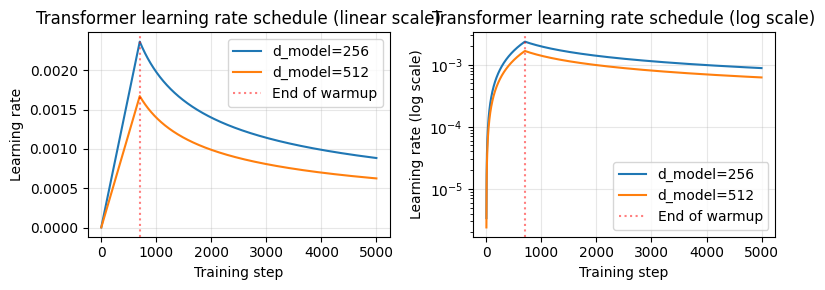


Example learning rates for d_model=256, warmup=700 steps:
  Step    1 (epoch 0.0): 0.000003
  Step  100 (epoch 0.3): 0.000337
  Step  350 (epoch 1.0): 0.001181
  Step  700 (epoch 2.0): 0.002362
  Step 1400 (epoch 4.0): 0.001670
  Step 2800 (epoch 8.0): 0.001181


In [3]:
# Import and visualize the learning rate schedule
from src import TransformerSchedule

# Create schedules for different d_model values  
d_models = [256, 512]
warmup_steps_viz = 700  # For visualization (approximately 2 epochs)
max_steps = 5000        # Show fewer steps for clarity

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Left plot: Linear scale
for d_model in d_models:
    schedule = TransformerSchedule(d_model=d_model, warmup_steps=warmup_steps_viz)
    steps = tf.range(1, max_steps, dtype=tf.float32)
    lrs = [schedule(step) for step in steps]
    axes[0].plot(steps, lrs, label=f'd_model={d_model}')

axes[0].axvline(x=warmup_steps_viz, color='red', linestyle=':', alpha=0.5, label='End of warmup')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Learning rate')
axes[0].set_title('Transformer learning rate schedule (linear scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Log scale
for d_model in d_models:
    schedule = TransformerSchedule(d_model=d_model, warmup_steps=warmup_steps_viz)
    steps = tf.range(1, max_steps, dtype=tf.float32)
    lrs = [schedule(step) for step in steps]
    axes[1].plot(steps, lrs, label=f'd_model={d_model}')

axes[1].axvline(x=warmup_steps_viz, color='red', linestyle=':', alpha=0.5, label='End of warmup')
axes[1].set_xlabel('Training step')
axes[1].set_ylabel('Learning rate (log scale)')
axes[1].set_title('Transformer learning rate schedule (log scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nExample learning rates for d_model=256, warmup={warmup_steps_viz} steps:')
schedule_256 = TransformerSchedule(d_model=256, warmup_steps=warmup_steps_viz)
for step in [1, 100, 350, 700, 1400, 2800]:
    epoch = step / 350  # Approximate with 350 steps/epoch
    lr = schedule_256(step)
    print(f'  Step {step:4d} (epoch {epoch:3.1f}): {lr.numpy():.6f}')

In [4]:
# ── Data configuration ──────────────────────────────────────────────────────────────
max_seq_length = 20         # Maximum tokens per sentence after tokenization
num_train_samples = 100000  # Limit training set size for reasonable training time

# ── Model architecture ──────────────────────────────────────────────────────────────
max_encoder_len = max_seq_length + 2  # +2 for BOS/EOS
max_decoder_len = max_seq_length + 4  # Extra space for decoder

# ── Model architecture ──────────────────────────────────────────────────────────────
d_model = 256              # Transformer embedding dimension
n_layers = 4               # Number of encoder/decoder layers
d_ff = 1024                # Feed-forward network dimension (4 × d_model)
dropout_rate = 0.1         # Dropout rate for regularization

# ── Training configuration ──────────────────────────────────────────────────────────
batch_size = 256           # Samples per gradient update
epochs = 100               # Maximum training epochs
validation_split = 0.1     # Fraction of data used for validation

# Learning rate configuration
use_warmup = True          # Use warmup schedule (required for embedding scaling)

# Calculate warmup steps based on dataset size
train_samples_adj = int(num_train_samples * (1 - validation_split))
steps_per_epoch = train_samples_adj // batch_size
warmup_epochs = 4.0        # Warmup duration in epochs
warmup_steps = int(steps_per_epoch * warmup_epochs)

# ── Callback configuration ──────────────────────────────────────────────────────────
bleu_sample_size = 20     # Number of samples for BLEU evaluation during training

print('Hyperparameters configured:\n')
print(f'  Data: max_seq_length={max_seq_length}, train_samples={num_train_samples:,}')
print(f'  Model: d_model={d_model}, n_layers={n_layers}, d_ff={d_ff}, dropout={dropout_rate}')
print(f'  Training: batch_size={batch_size}, epochs={epochs}')
print(f'  Steps per epoch: {steps_per_epoch}\n')

if use_warmup:
    peak_lr = (d_model ** -0.5) * (warmup_steps ** -0.5)
    print(f'  Learning rate: TransformerSchedule with warmup\n')
    print(f'    Warmup steps: {warmup_steps} ({warmup_epochs} epochs)')
    print(f'    Peak LR: ~{peak_lr:.6f}')
    print(f'    Schedule: Linear warmup then inverse sqrt decay')
else:
    print(f'  Learning rate: Fixed LR=0.0003')

Hyperparameters configured:

  Data: max_seq_length=20, train_samples=100,000
  Model: d_model=256, n_layers=4, d_ff=1024, dropout=0.1
  Training: batch_size=256, epochs=100
  Steps per epoch: 351

  Learning rate: TransformerSchedule with warmup

    Warmup steps: 1404 (4.0 epochs)
    Peak LR: ~0.001668
    Schedule: Linear warmup then inverse sqrt decay


## 2. Data preparation

### 2.1. Load dataset

In [5]:
# Load OPUS-100 English-French dataset
dataset = load_dataset('Helsinki-NLP/opus-100', 'en-fr')

# Filter by sequence length and sample
def filter_length(example):
    en_length = len(example['translation']['en'].split())
    fr_length = len(example['translation']['fr'].split())
    return en_length <= max_seq_length and fr_length <= max_seq_length

filtered_dataset = dataset['train'].filter(filter_length)
sampled_dataset = filtered_dataset.select(range(min(num_train_samples, len(filtered_dataset))))

# Extract parallel sentences
pairs = [(item['translation']['en'], item['translation']['fr']) for item in sampled_dataset]

print(f'Loaded {len(pairs):,} training pairs')
print(f'Max sequence length: {max_seq_length} tokens')
print(f'\nExample pairs:')

for i in range(3):
    en, fr = pairs[i]
    print(f'  EN: {en}')
    print(f'  FR: {fr}')
    print()

Loaded 100,000 training pairs
Max sequence length: 20 tokens

Example pairs:
  EN: The time now is 05:08 .
  FR: The time now is 05:05 .

  EN: Hello, what's that?
  FR: Qu'est-ce que c'est que ça ?

  EN: And then I will teach you everything i know.
  FR: Et alors, je t'apprendrai tout ce que je sais.



### 2.2. Tokenization

In [6]:
# Load pre-trained MarianTokenizer
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')

num_tokens = len(tokenizer)

print(f'Vocabulary size: {num_tokens:,} tokens')
print(f'Max encoder length: {max_encoder_len}')
print(f'Max decoder length: {max_decoder_len}')
print(f'PAD token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})')
print(f'EOS token: {tokenizer.eos_token} (id={tokenizer.eos_token_id})')

Vocabulary size: 59,514 tokens
Max encoder length: 22
Max decoder length: 24
PAD token: <pad> (id=59513)
EOS token: </s> (id=0)


### 2.3. Prepare training data

Create input sequences for the transformer:
- **Encoder input**: Source language tokens
- **Decoder input**: Target language tokens (shifted right, starts with PAD as BOS)
- **Decoder target**: Target language tokens (ground truth)

In [7]:
# Tokenize all pairs
encoder_inputs = tokenizer(
    [en for en, _ in pairs], 
    padding='max_length',
    truncation=True,
    max_length=max_encoder_len,
    return_tensors='np'
)

decoder_inputs = tokenizer(
    [fr for _, fr in pairs],
    padding='max_length', 
    truncation=True,
    max_length=max_decoder_len,
    return_tensors='np'
)

# Extract arrays
encoder_input_data = encoder_inputs['input_ids']
decoder_input_texts = [fr for _, fr in pairs]

# Prepare decoder inputs (shift right, start with PAD as BOS)
raw_decoder_tokens = decoder_inputs['input_ids']
decoder_input_data = np.zeros_like(raw_decoder_tokens)
decoder_input_data[:, 0] = tokenizer.pad_token_id
decoder_input_data[:, 1:] = raw_decoder_tokens[:, :-1]

# Decoder targets (ground truth)
decoder_target_data = raw_decoder_tokens

print(f'Encoder input shape: {encoder_input_data.shape}')
print(f'Decoder input shape: {decoder_input_data.shape}')
print(f'Decoder target shape: {decoder_target_data.shape}')

Encoder input shape: (100000, 22)
Decoder input shape: (100000, 24)
Decoder target shape: (100000, 24)


## 3. Model definitions

This section defines all model components for the transformer architecture. We build:
1. **Positional encoding**: Adds position information to embeddings
2. **Training model**: Combines encoder and decoder stacks
3. **Translation function**: Greedy decoding for generating translations

### 3.1. Positional encoding

Since transformers process sequences in parallel (not sequentially like LSTMs), we must explicitly encode position information. The transformer uses sine/cosine functions at different frequencies to create unique positional encodings for each position.

Each position gets a unique encoding across all $d_{model}$ dimensions. Different dimensions use different frequencies, so lower dimensions change rapidly across positions while higher dimensions change slowly. This visualization shows how different embedding dimensions (y-axis) encode different position frequencies (x-axis):

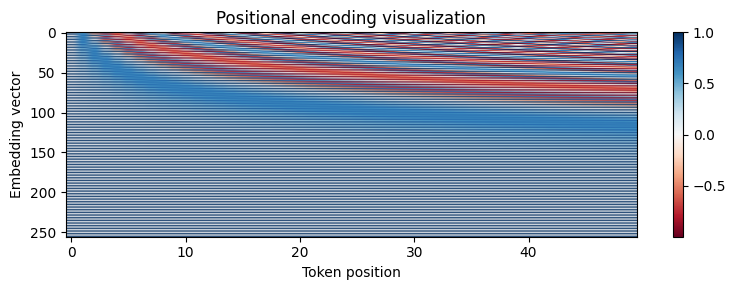

Positional encoding shape: (50, 256)


In [8]:
# Import positional encoding function from src module
from src.models import get_positional_encoding

# Visualize positional encoding
pos_enc = get_positional_encoding(50, 256)
plt.figure(figsize=(8, 3))
plt.imshow(pos_enc.numpy().T, aspect='auto', cmap='RdBu')
plt.colorbar()
plt.xlabel('Token position')
plt.ylabel('Embedding vector')
plt.title('Positional encoding visualization')
plt.tight_layout()
plt.show()

print('Positional encoding shape:', pos_enc.shape)

### 3.2. Training model

The transformer model uses self-attention and cross-attention mechanisms with positional encodings. Unlike the LSTM model, transformers process sequences in parallel, making training more efficient.

Key components (all implemented using Keras layers):
- **Positional Encoding**: Adds position information via sine/cosine functions
- **Encoder Layers**: Self-attention + feed-forward network with residual connections
- **Decoder Layers**: Masked self-attention + cross-attention + feed-forward network
- **Attention**: Uses the same `layers.Attention` (dot-product) from the LSTM model

**Transformer architecture:**

```text
      ENCODER                                                 DECODER
                                                          
  Input: "Hello world"                               Target: "<s> Bonjour monde"
          │                                                      │
          ▼                                                      ▼
   ┌──────────────┐                                       ┌──────────────┐
   │  Embedding   │                                       │  Embedding   │
   └──────┬───────┘                                       └──────┬───────┘
          │                                                      │
          ▼                                                      ▼
   ┌──────────────┐                                       ┌──────────────┐
   │ Positional   │                                       │  Positional  │
   │  Encoding    │                                       │   Encoding   │
   └──────┬───────┘                                       └──────┬───────┘
          │                                                      │
          ▼                                                      ▼
   ┌──────────────┐       Encoder output vectors         ┌───────────────┐
   │     Self     │ ────────────────────────────────────►│    Masked     │
   │  Attention   │      (all encoder positions)         │     Self      │
   │  (parallel)  │                                      │   Attention   │
   └──────┬───────┘                                      │   (causal)    │
          │                                              └───────┬───────┘
          ▼                                                      │
   ┌──────────────┐                                              ▼
   │ Feed Forward │                                      ┌───────────────┐
   │   Network    │                                      │    Cross      │
   └──────┬───────┘          ┌──────────────────────────►│  Attention    │
          │                  │                           │ (to encoder)  │
          ▼                  │                           └───────┬───────┘
   ┌──────────────┐          │                                   │
   │ Layer Norm + │          │                                   ▼
   │   Residual   │          │                           ┌───────────────┐
   └──────┬───────┘          │                           │ Feed Forward  │
          │                  │                           │   Network     │
          ▼                  │                           └───────┬───────┘
  (repeat N layers)          │                                   │
          │                  │                                   ▼
          │                  │                           ┌───────────────┐
          │                  │                           │ Layer Norm +  │
          └──────────────────┘                           │   Residual    │
                                                         └───────┬───────┘
                                                                 │
                                                                 ▼
                                                        (repeat N layers)
                                                                 │
                                                                 ▼
                                                         ┌───────────────┐
                                                         │    Dense      │
                                                         │  (softmax)    │
                                                         └───────┬───────┘
                                                                 │
                                                                 ▼
                                                           Output sequence
                                                                 │
                                                    ┌────────────┴────────────┐
                                                    ▼                         ▼
                                         Labels (shifted target)         Predictions
                                          "Bonjour monde </s>"       "Bonjour monde </s>"
                                                    │                         │
                                                    └─────────► Loss ◄────────┘
```

In [9]:
# Import model building function from src module
from src import build_transformer_model

# Build and compile transformer
model = build_transformer_model(
    num_tokens=num_tokens,
    max_encoder_len=max_encoder_len,
    max_decoder_len=max_decoder_len,
    d_model=d_model,
    n_layers=n_layers,
    d_ff=d_ff,
    dropout_rate=dropout_rate,
    warmup_steps=warmup_steps,
    use_warmup=use_warmup
)

print('Transformer model built')
print(f'Parameters: d_model={d_model}, n_layers={n_layers}, d_ff={d_ff}')
print(f'Dropout rate: {dropout_rate}')

# Show model summary
if use_warmup:
    print(f'Using warmup schedule with {warmup_steps} steps')
    print(f'Peak learning rate: ~{(d_model ** -0.5) * (warmup_steps ** -0.5):.6f} (at step {warmup_steps})')
else:
    print('Using fixed learning rate: 0.0003 (no warmup, no embedding scaling)')

Using warmup schedule: d_model=256, warmup_steps=1404
Transformer model built
Parameters: d_model=256, n_layers=4, d_ff=1024
Dropout rate: 0.1
Using warmup schedule with 1404 steps
Peak learning rate: ~0.001668 (at step 1404)


### 3.3. Translation function

The translation function implements greedy decoding for the transformer. Unlike the LSTM model, we don't need separate inference models - we can use the trained model directly for generation since the transformer's architecture naturally supports autoregressive decoding.

In [10]:
# Import translate function from src module
from src import translate_transformer

## 4. Model training

### 4.1. Callbacks

In [11]:
# Import BLEU callback and dummy inference function from src module
from src import BLEUCallback, build_inference_models_transformer

# Create directories for checkpoints and logs
model_dir = '../models/transformer'
checkpoint_dir = f'{model_dir}/checkpoints'
log_dir = '../logs/transformer'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

callbacks = [

    # BLEU evaluation/checkpointing callback
    BLEUCallback(
        pairs=pairs,
        tokenizer=tokenizer,
        max_encoder_len=max_encoder_len,
        max_decoder_len=max_decoder_len,
        translate_fn=translate_transformer,
        build_inference_fn=build_inference_models_transformer,
        checkpoint_dir=checkpoint_dir,
        sample_size=bleu_sample_size,
        latent_dim=d_model,
        restore_best_weights=True
    ),

    # TensorBoard callback for training visualization
    TensorBoard(
        log_dir=os.path.join(log_dir, datetime.now().strftime('%Y%m%d-%H%M%S')),
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

# TransformerSchedule handles all learning rate adjustments automatically

### 4.2. Train

In [ ]:
start_time = time.time()

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    verbose=0,
    callbacks=callbacks
)

dt = time.time() - start_time

In [ ]:
print(f'Best BLEU score: {callbacks[0].best_bleu:.2f}')
print(f'Runtime: {(dt / (60 * 60)):.2f} hrs')

In [ ]:
# Save training metrics
bleu_callback = callbacks[0]

# Create complete training history with BLEU scores
training_history = {
    'loss': history.history['loss'],
    'accuracy': history.history['accuracy'],
    'val_loss': history.history['val_loss'],
    'val_accuracy': history.history['val_accuracy'],
    'bleu_score': bleu_callback.bleu_scores
}

# Prepare checkpoint filename
checkpoint_filename = f'model_epoch_{bleu_callback.best_epoch+1:02d}_best_bleu_{bleu_callback.best_bleu:.2f}.h5'

# Create metrics dictionary
training_metrics = {
    'training_history': training_history,
    'best_epoch': bleu_callback.best_epoch,
    'best_bleu': bleu_callback.best_bleu,
    'checkpoint_file': checkpoint_filename
}

# Save to file
metrics_path = Path(model_dir) / 'training_metrics.json'

with open(metrics_path, 'w') as f:
    json.dump(training_metrics, f, indent=2)

print(f'Saved training metrics to {metrics_path}')

### 4.3. Learning curves

**Viewing TensorBoard logs:** To visualize training metrics (loss, accuracy, BLEU score) in TensorBoard:
1. Open the Command Palette (Ctrl+Shift+P / Cmd+Shift+P)
2. Run **Python: Launch TensorBoard**
3. Select the log directory: `logs/transformer/<RUN_DATE-TIME>`
4. TensorBoard will open in a new VS Code panel

In [ ]:
# Plot learning curves: loss, accuracy, and BLEU
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

# Epoch where best BLEU was achieved (model weights restored from here)
best_epoch = training_metrics['best_epoch']

# Left plot: training vs validation loss
# Overfitting visible when validation loss increases while training loss decreases
axes[0].set_title('Loss')
axes[0].plot(training_metrics['training_history']['loss'], label='Train')
axes[0].plot(training_metrics['training_history']['val_loss'], label='Validation')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')

# Middle plot: token-level accuracy
# Shows fraction of correctly predicted tokens (inflated by padding tokens)
axes[1].set_title('Token accuracy')
axes[1].plot(training_metrics['training_history']['accuracy'], label='Train')
axes[1].plot(training_metrics['training_history']['val_accuracy'], label='Validation')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

# Right plot: BLEU score over training
# Marker shows best checkpoint (weights restored from this epoch)
axes[2].set_title('Validation BLEU score')
axes[2].plot(training_metrics['training_history']['bleu_score'], c='black', label='BLEU score')
axes[2].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BLEU')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()

**Note:** The loss and accuracy curves show clear overfitting (validation plateaus while training improves), yet BLEU continues to increase. Why?

- **Loss/accuracy** are computed using **teacher forcing** - the model sees ground truth previous tokens
- **BLEU** evaluates **autoregressive generation** - the model sees its own predictions

These are fundamentally different tasks. A model can memorize training sequences (overfitting the teacher-forcing objective) while its ability to generate coherent translations continues improving as embeddings become richer and general translation patterns solidify.

## 5. Evaluation

### 5.1. BLEU evaluation

Evaluate the trained transformer model on a larger sample of sentence pairs to measure translation quality. The BLEU score provides a quantitative measure of how well the model's translations match human references.

In [ ]:
# Evaluate on a larger sample than used during training callback
np.random.seed(315)
sample_indices = np.random.choice(len(pairs), size=min(200, len(pairs)), replace=False)

# Collect model predictions and ground truth
hypotheses = []  # Model translations
references = []  # Ground truth translations

print('Generating translations for BLEU evaluation...')

for i, idx in enumerate(sample_indices):
    
    en_text, fr_ref = pairs[idx]
    fr_hyp = translate_transformer(en_text, model, tokenizer, max_encoder_len, max_decoder_len)
    
    hypotheses.append(fr_hyp)
    references.append(fr_ref)
    
    # Progress indicator
    if (i + 1) % 50 == 0:
        print(f'  Processed {i + 1}/{len(sample_indices)} samples')

# Compute corpus-level BLEU (aggregates n-gram precision across all sentences)
bleu = BLEU()
result = bleu.corpus_score(hypotheses, [references])

print(f'\nBLEU score: {result.score:.2f}')
print(f'Breakdown: {result}')

# Qualitative analysis: inspect individual translations
print('\nSample predictions vs references:')

for i in range(10):
    
    print(f'  Source: {pairs[sample_indices[i]][0]}')
    print(f'  Reference: {references[i]}')
    print(f'  Hypothesis: {hypotheses[i]}\n')

### 5.2. Compare with LSTM models

Load BLEU scores from training metrics to compare performance across architectures.

In [ ]:
# Load metrics from all models
models_to_compare = {
    'LSTM': '../models/lstm/training_metrics.json',
    'LSTM + Attention': '../models/lstm-attention/training_metrics.json',
    'Transformer': '../models/transformer/training_metrics.json'
}

comparison_data = {}

for name, path in models_to_compare.items():
    if os.path.exists(path):
        with open(path, 'r') as f:
            metrics = json.load(f)
            comparison_data[name] = {
                'best_bleu': metrics['best_bleu'],
                'best_epoch': metrics['best_epoch'],
                'bleu_history': metrics['training_history']['bleu_score']
            }

# Plot comparison
plt.figure(figsize=(10, 6))

for name, data in comparison_data.items():
    plt.plot(data['bleu_history'], label=f"{name} (best: {data['best_bleu']:.2f})")

plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.title('Model comparison: BLEU score evolution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print('\nModel performance summary:')
print('-' * 50)

for name, data in comparison_data.items():
    print(f"{name:20s} Best BLEU: {data['best_bleu']:6.2f} (epoch {data['best_epoch']+1})")

## 6. The transformer family

The transformer architecture introduced in "Attention is All You Need" (2017) became the foundation for modern NLP. While we implemented an encoder-decoder model for translation, the transformer's modular design spawned specialized variants optimized for different tasks.

### Architecture variants

The original transformer has three main components that can be used independently:

**1. Encoder only (BERT family)**
- **Architecture**: Only the encoder stack (self-attention + feed-forward)
- **Training**: Masked language modeling (predict masked tokens)
- **Use cases**: Text classification, named entity recognition, question answering
- **Examples**: BERT, RoBERTa, DistilBERT
- **Key insight**: Bidirectional context (can see both left and right)

**2. Decoder only (GPT family)**
- **Architecture**: Only the decoder stack (causal self-attention + feed-forward)
- **Training**: Autoregressive language modeling (predict next token)
- **Use cases**: Text generation, completion, few-shot learning
- **Examples**: GPT-2, GPT-3, GPT-4, LLaMA
- **Key insight**: Unidirectional context (only sees left, generates right)

**3. Encoder-decoder (T5 family)**
- **Architecture**: Full transformer (both encoder and decoder)
- **Training**: Span corruption (predict masked spans)
- **Use cases**: Translation, summarization, question answering (as text generation)
- **Examples**: T5, BART, mT5
- **Key insight**: Flexible input-output (any text-to-text task)

### Transformer family tree

Our journey through neural machine translation and the broader transformer ecosystem:

```text
                           Architecture evolution
                                      
                      ENCODER-DECODER LSTM (Notebook 1)
                  Sutskever et al. 2014 - 'Seq2Seq with RNNs'
                              [Sequential RNN]
                                     |
                                     ↓
                   ENCODER-DECODER LSTM + ATTENTION (Notebook 2)
                    Bahdanau et al. 2015 - 'Align and Translate'
                        [RNN with attention mechanism]
                                     |
                                     ↓
                    ENCODER-DECODER TRANSFORMER (Notebook 3)
                Vaswani et al. 2017 - 'Attention is All You Need'
                         [Parallel self-attention]
                                     |
                                     |
              _______________________|_______________________
             |                       |                       |
             |                       |                       |
       ENCODER ONLY            DECODER ONLY           ENCODER-DECODER
      (Bidirectional)        (Autoregressive)           (Seq-to-Seq)
             |                       |                       |
             |                       |                       |
        BERT (2018)              GPT (2018)              T5 (2019)
     Text understanding       Text generation           Text-to-text
             |                       |                       |
             ↓                       ↓                       ↓
        - RoBERTa              - GPT-2, GPT-3             - BART
        - DistilBERT           - ChatGPT                  - mT5
        - ALBERT               - GPT-4                    - mBART
        - ELECTRA              - LLaMA, Mistral
```

### Task-specific design choices

**Why encoder-only for understanding tasks?**
- Needs full context (both directions) to understand meaning
- Example: "The bank was steep" vs "I went to the bank"
- Classification needs to see entire sentence to disambiguate
- Bidirectional attention captures relationships in all directions

**Why decoder-only for generation tasks?**
- Generates tokens left-to-right (autoregressive)
- Training matches inference (both predict next token)
- Example: "The cat sat on the ___" → predicts "mat"
- Causal masking prevents looking ahead during training

**Why encoder-decoder for sequence-to-sequence?**
- Input and output have different structures
- Example: English → French, long document → summary
- Encoder: bidirectional understanding of source
- Decoder: autoregressive generation of target
- Cross-attention: aligns source and target

### T5 unified framework

T5 (Text-to-Text Transfer Transformer) reframes all NLP tasks as text generation:

```text
Translation:      "translate English to French: Hello" → "Bonjour"
Classification:   "sentiment: This movie is great"     → "positive"
Summarization:    "summarize: [long text]"             → "[summary]"
Question answer:  "question: Who? context: [text]"     → "John"
```

This unified approach means:
- Same architecture for all tasks
- Task specified by input prefix
- All outputs are generated text
- Single model can handle multiple tasks